Normal distribution: U = -0.0088
Lognormal distribution: U = -2.7404

Normal - skewness: 0.0020
Lognormal - skewness: 1.8936


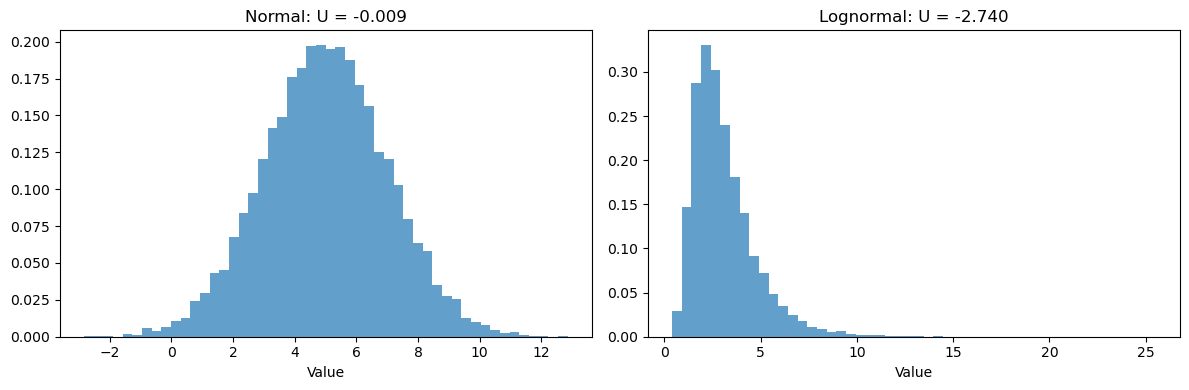

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def binder_cumulant(data):
    """Binder cumulant for fluctuations δM = M - <M>"""
    delta_M = data - np.mean(data)
    m2 = np.mean(delta_M**2)
    m4 = np.mean(delta_M**4)
    U = 1 - m4 / (3 * m2**2)
    return U

# Generate data
np.random.seed(42)
n = 10000

# Normal distribution (symmetric, no tail)
normal_data = np.random.normal(loc=5, scale=2, size=n)

# Lognormal distribution (long right tail)
lognormal_data = np.random.lognormal(mean=1, sigma=0.5, size=n)

# Compute Binder cumulants
U_normal = binder_cumulant(normal_data)
U_lognormal = binder_cumulant(lognormal_data)

print(f"Normal distribution: U = {U_normal:.4f}")
print(f"Lognormal distribution: U = {U_lognormal:.4f}")
print(f"\nNormal - skewness: {np.mean((normal_data - np.mean(normal_data))**3) / np.std(normal_data)**3:.4f}")
print(f"Lognormal - skewness: {np.mean((lognormal_data - np.mean(lognormal_data))**3) / np.std(lognormal_data)**3:.4f}")

# Plot distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(normal_data, bins=50, density=True, alpha=0.7)
ax1.set_title(f'Normal: U = {U_normal:.3f}')
ax1.set_xlabel('Value')

ax2.hist(lognormal_data, bins=50, density=True, alpha=0.7)
ax2.set_title(f'Lognormal: U = {U_lognormal:.3f}')
ax2.set_xlabel('Value')

plt.tight_layout()
plt.show()